# Eurostat & Climate DT Visualisation

This notebook has three parts:

1. **Eurostat** — fetch life-expectancy-at-birth data from the Eurostat API and plot it as a choropleth map of Europe.
2. **Climate DT** — fetch 2 m temperature for the same set of countries from the DestinE Climate DT via Polytope and plot it in the same style.
3. **Climate Health Hazard Index** — combine Climate DT summer heat (present baseline and SSP3-7.0 future) with Eurostat elderly population share to produce a composite hazard score per country, shown as three maps: present, future, and the change between them.

All maps use the same NUTS Level-0 shapefile and the same `earthkit.plots` rendering pipeline so the results are directly comparable.

---
## Part 1 — Eurostat life expectancy

In [43]:
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import earthkit.plots

url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/tps00205?lang=EN&time=2024"
resp = requests.get(url)
data = resp.json()

In [44]:
geo_code = data['dimension']["geo"]["category"]["index"]
new_dict = []
for key, value in geo_code.items():
    if str(value) in data['value'] and key != 'EU27_2020':
        new_dict.append((key, data['value'][str(value)]))

In [45]:
df = pd.DataFrame(new_dict, columns=["geo", "value"])
df

,geo,value
0,EA21,82.2
1,EA20,82.4
2,EA19,82.4
3,BE,82.4
4,BG,75.8
5,CZ,80.1
6,DK,82.0
7,DE,81.2
8,EE,79.7
9,IE,83.1


In [46]:
# Path to your local shapefile archive
shapefile_path = "data/NUTS_RG_20M_2021_4326_LEVL_0.shp.zip"

# Load the shapefile into a GeoDataFrame
gdf = gpd.read_file(f"zip://{shapefile_path}")
gdf

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,FR,0,FR,France,France,0,0,0,"MULTIPOLYGON (((55.21471 -21.03851, 55.27392 -..."
1,HR,0,HR,Hrvatska,Hrvatska,0,0,0,"MULTIPOLYGON (((16.59681 46.4759, 16.85476 46...."
2,HU,0,HU,Magyarország,Magyarország,0,0,0,"POLYGON ((21.42465 48.57472, 21.60691 48.49458..."
3,AL,0,AL,Shqipëria,Shqipëria,0,0,0,"POLYGON ((19.73492 42.63238, 19.831 42.46645, ..."
4,AT,0,AT,Österreich,Österreich,0,0,0,"POLYGON ((15.75363 48.85218, 16.29009 48.73395..."
5,BE,0,BE,Belgique/België,Belgique/België,0,0,0,"POLYGON ((4.75993 51.50246, 4.864 51.43362, 5...."
6,BG,0,BG,Bulgaria,България,0,0,0,"POLYGON ((22.85777 43.87577, 22.99717 43.80787..."
7,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,0,0,0,"POLYGON ((8.67046 47.68486, 8.79571 47.6756, 8..."
8,CY,0,CY,Kýpros,Κύπρος,0,0,0,"POLYGON ((32.27382 35.06649, 32.28884 35.10503..."
9,CZ,0,CZ,Česko,Česko,0,0,0,"POLYGON ((14.6188 50.8578, 14.76738 50.81985, ..."


In [47]:
# Create color scale
cmap = plt.get_cmap("Reds")

# Normalize values between 0 and 1 for color mapping
norm = plt.Normalize(vmin=df["value"].min(), vmax=df["value"].max())

# Map numeric values to colors in hex format
df["facecolor"] = df["value"].apply(lambda x: plt.cm.colors.to_hex(cmap(norm(x))))

print(df)

     geo  value facecolor
0   EA21   82.2   #c1161b
1   EA20   82.4   #b91419
2   EA19   82.4   #b91419
3     BE   82.4   #b91419
4     BG   75.8   #fee5d9
5     CZ   80.1   #f5533b
6     DK   82.0   #c7171c
7     DE   81.2   #e02c26
8     EE   79.7   #f96346
9     IE   83.1   #a10e15
10    EL   81.9   #ca181d
11    ES   84.0   #71020e
12    FR   83.0   #a60f15
13    HR   78.9   #fc8060
14    IT   83.7   #800610
15    CY   83.5   #8c0912
16    LV   76.4   #fdd5c4
17    LT   77.5   #fcb296
18    LU   83.2   #9c0d14
19    HU   76.8   #fdc9b3
20    MT   83.0   #a60f15
21    NL   81.9   #ca181d
22    AT   82.1   #c3161b
23    PL   78.5   #fc8e6e
24    PT   82.5   #b61319
25    RO   76.5   #fdd2bf
26    SI   82.1   #c3161b
27    SK   78.4   #fc9272
28    FI   82.2   #c1161b
29    SE   83.8   #7c0510
30    IS   82.8   #ac1117
31    LI   84.2   #67000d
32    NO   83.2   #9c0d14
33    CH   84.2   #67000d
34    ME   77.6   #fcae92
35    AL   80.4   #f24734
36    RS   76.2   #fedccd
37    TR   7

In [48]:
# Merge — keep all geometries, even if no data
gdf_full = gdf.merge(
    df,
    left_on="NUTS_ID",
    right_on="geo",
    how="left"
)

# Convert to GeoDataFrame if needed
if not isinstance(gdf_full, gpd.GeoDataFrame):
    gdf_full = gpd.GeoDataFrame(gdf_full, geometry=gdf.geometry, crs=gdf.crs)

gdf_full["facecolor"] = gdf_full["facecolor"].fillna("#cccccc")
gdf_full

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry,geo,value,facecolor
0,FR,0,FR,France,France,0,0,0,"MULTIPOLYGON (((55.21471 -21.03851, 55.27392 -...",FR,83.0,#a60f15
1,HR,0,HR,Hrvatska,Hrvatska,0,0,0,"MULTIPOLYGON (((16.59681 46.4759, 16.85476 46....",HR,78.9,#fc8060
2,HU,0,HU,Magyarország,Magyarország,0,0,0,"POLYGON ((21.42465 48.57472, 21.60691 48.49458...",HU,76.8,#fdc9b3
3,AL,0,AL,Shqipëria,Shqipëria,0,0,0,"POLYGON ((19.73492 42.63238, 19.831 42.46645, ...",AL,80.4,#f24734
4,AT,0,AT,Österreich,Österreich,0,0,0,"POLYGON ((15.75363 48.85218, 16.29009 48.73395...",AT,82.1,#c3161b
5,BE,0,BE,Belgique/België,Belgique/België,0,0,0,"POLYGON ((4.75993 51.50246, 4.864 51.43362, 5....",BE,82.4,#b91419
6,BG,0,BG,Bulgaria,България,0,0,0,"POLYGON ((22.85777 43.87577, 22.99717 43.80787...",BG,75.8,#fee5d9
7,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,0,0,0,"POLYGON ((8.67046 47.68486, 8.79571 47.6756, 8...",CH,84.2,#67000d
8,CY,0,CY,Kýpros,Κύπρος,0,0,0,"POLYGON ((32.27382 35.06649, 32.28884 35.10503...",CY,83.5,#8c0912
9,CZ,0,CZ,Česko,Česko,0,0,0,"POLYGON ((14.6188 50.8578, 14.76738 50.81985, ...",CZ,80.1,#f5533b


In [49]:
# Merge on country code — only keep countries with data
gdf_joined = gdf.merge(
    df,
    left_on="NUTS_ID",
    right_on="geo",
    how="inner"
)

# Ensure result is a GeoDataFrame with correct geometry
gdf_joined = gpd.GeoDataFrame(gdf_joined, geometry="geometry", crs=gdf.crs)

# Drop redundant columns
gdf_joined = gdf_joined[["NUTS_ID", "value", "facecolor", "geometry"]]
gdf_joined

,NUTS_ID,value,facecolor,geometry
0,FR,83.0,#a60f15,"MULTIPOLYGON (((55.21471 -21.03851, 55.27392 -..."
1,HR,78.9,#fc8060,"MULTIPOLYGON (((16.59681 46.4759, 16.85476 46...."
2,HU,76.8,#fdc9b3,"POLYGON ((21.42465 48.57472, 21.60691 48.49458..."
3,AL,80.4,#f24734,"POLYGON ((19.73492 42.63238, 19.831 42.46645, ..."
4,AT,82.1,#c3161b,"POLYGON ((15.75363 48.85218, 16.29009 48.73395..."
5,BE,82.4,#b91419,"POLYGON ((4.75993 51.50246, 4.864 51.43362, 5...."
6,BG,75.8,#fee5d9,"POLYGON ((22.85777 43.87577, 22.99717 43.80787..."
7,CH,84.2,#67000d,"POLYGON ((8.67046 47.68486, 8.79571 47.6756, 8..."
8,CY,83.5,#8c0912,"POLYGON ((32.27382 35.06649, 32.28884 35.10503..."
9,CZ,80.1,#f5533b,"POLYGON ((14.6188 50.8578, 14.76738 50.81985, ..."


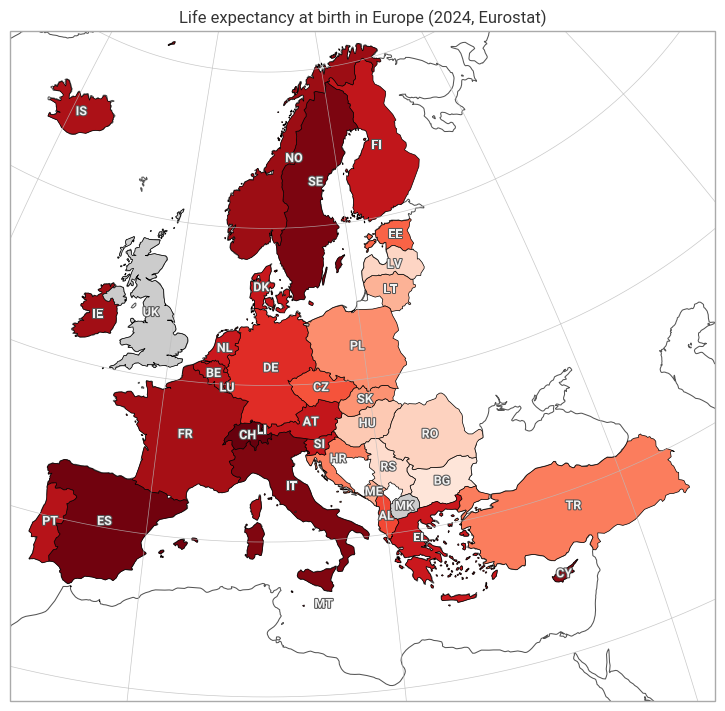

In [50]:
chart = earthkit.plots.Map(domain="Europe")

chart.coastlines()
chart.shapes(
    shapefile_path,
    labels="NUTS_ID",
    facecolor=gdf_full['facecolor'],
    cmap="Reds",
    edgecolor="black",
    linewidth=0.5,
)
chart.gridlines(draw_labels=False)
chart.title("Life expectancy at birth in Europe (2024, Eurostat)")
chart.show()

---
## Part 2 — Climate DT 2 m temperature via Polytope

For each country in the Eurostat dataset we fetch the monthly-mean 2 m temperature (`avg_2t`) from the DestinE Climate DT (IFS-NEMO, historical run) using a **timeseries** feature request at the country centroid.  
The resulting per-country average is then plotted on the same NUTS Level-0 map.

> **Note:** You need a valid DESP account with Climate DT access.  
> Run `desp-authentication.py` once to store your token in `~/.polytopeapirc`.

In [59]:
#%%capture cap
#%run ../../desp-authentication.py

In [60]:
#output_1 = cap.stdout.split('}\n')
#access_token = output_1[-1][0:-1]

In [51]:
import earthkit.data
import numpy as np

# Set to False to load from a previously saved cache file instead of making live requests
import os
LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
print(f"LIVE_REQUEST = {LIVE_REQUEST}")

LIVE_REQUEST = True


In [52]:
# Mapping from Eurostat NUTS-0 code → (country name for display, centroid lat, centroid lon)
# Centroids are approximate geographic centres used as the timeseries point.
COUNTRY_CENTROIDS = {
    "BE": ("Belgium",        50.85,   4.35),
    "BG": ("Bulgaria",       42.73,  25.48),
    "CZ": ("Czechia",        49.82,  15.47),
    "DK": ("Denmark",        56.26,   9.50),
    "DE": ("Germany",        51.17,  10.45),
    "EE": ("Estonia",        58.60,  25.01),
    "EL": ("Greece",         39.07,  21.82),
    "ES": ("Spain",          40.42,  -3.70),
    "FR": ("France",         46.23,   2.21),
    "HR": ("Croatia",        45.10,  15.20),
    "IT": ("Italy",          41.87,  12.57),
    "CY": ("Cyprus",         35.13,  33.43),
    "LV": ("Latvia",         56.88,  24.60),
    "LT": ("Lithuania",      55.17,  23.88),
    "LU": ("Luxembourg",     49.82,   6.13),
    "HU": ("Hungary",        47.16,  19.50),
    "MT": ("Malta",          35.94,  14.38),
    "NL": ("Netherlands",    52.13,   5.29),
    "AT": ("Austria",        47.52,  14.55),
    "PL": ("Poland",         51.92,  19.15),
    "PT": ("Portugal",       39.40,  -8.22),
    "RO": ("Romania",        45.94,  24.97),
    "SI": ("Slovenia",       46.15,  14.99),
    "SK": ("Slovakia",       48.67,  19.70),
    "FI": ("Finland",        61.92,  25.75),
    "SE": ("Sweden",         60.13,  18.64),
    "IS": ("Iceland",        64.96, -19.02),
    "LI": ("Liechtenstein",  47.14,   9.55),
    "NO": ("Norway",         60.47,   8.47),
    "CH": ("Switzerland",    46.82,   8.23),
}

print(f"{len(COUNTRY_CENTROIDS)} countries defined")

30 countries defined


In [53]:
# ── Configuration ────────────────────────────────────────────────────────────
CDT_YEAR   = "2010"
CDT_MONTH  = "6"    # June (historical run)
CDT_MODEL  = "ifs-nemo"
CDT_PARAM  = "avg_2t"   # Time-mean 2 m temperature [K]
CDT_ADDRESS = "polytope.mn5.apps.dte.destination-earth.eu"
CACHE_FILE  = "data/eurostat_cdt_2t_per_country.covjson"

# Build a list of [lat, lon] points — one per country, in the same order as COUNTRY_CENTROIDS
country_codes  = list(COUNTRY_CENTROIDS.keys())
centroid_points = [[v[1], v[2]] for v in COUNTRY_CENTROIDS.values()]

request = {
    "activity":   "baseline",
    "class":      "d1",
    "dataset":    "climate-dt",
    "experiment": "hist",
    "generation": "2",
    "levtype":    "sfc",
    "year":       CDT_YEAR,
    "month":      CDT_MONTH,
    "model":      CDT_MODEL,
    "expver":     "0001",
    "param":      CDT_PARAM,
    "realization": "1",
    "resolution": "standard",
    "stream":     "clmn",
    "type":       "fc",
    "feature": {
        "type":      "timeseries",
        "points":    centroid_points,
        "time_axis": "month",
    },
}

print(f"Requesting {CDT_PARAM} for {len(centroid_points)} country centroids — {CDT_YEAR}/{CDT_MONTH}")

Requesting avg_2t for 30 country centroids — 2010/6


In [54]:
if LIVE_REQUEST:
    cdt_data = earthkit.data.from_source(
        "polytope", "destination-earth", request,
        address=CDT_ADDRESS, stream=False
    )
    cdt_data.to_target("file", CACHE_FILE)
else:
    cdt_data = earthkit.data.from_source("file", CACHE_FILE)

2026-05-22 11:36:30 - INFO - Key read from /Users/maaw/.polytopeapirc
2026-05-22 11:36:30 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 50.85\n'
            '    - 4.35\n'
            '  - - 42.73\n'
            '    - 25.48\n'
            '  - - 49.82\n'
            '    - 15.47\n'
            '  - - 56.26\n'
            '    - 9.5\n'
            '  - - 51.17\n'
            '    - 10.45\n'
            '  - - 58.6\n'
            '    - 25.01\n'
            '  - - 39.07\n'
            '    - 21.82\n'
            '  - - 40.42\n'
            '    - -3.7\n'
            '  - - 46.23\n'
            '    - 2.21\n'
            '  - - 45.1\n'
            '    - 15.2\n'
            '  - - 41.87\n'
            '    - 12.57\n'
            '  - - 35.13\n'
            '    - 33.43\n'
      

2026-05-22 11:36:31 - INFO - Request accepted. Please poll ./28f72498-ec01-4107-ac9b-8d02d12a77c9 for status
2026-05-22 11:36:31 - INFO - Polytope user key found in session cache for user maaw
2026-05-22 11:36:31 - INFO - Checking request status (28f72498-ec01-4107-ac9b-8d02d12a77c9)...
2026-05-22 11:36:31 - INFO - The current status of the request is 'queued'
2026-05-22 11:36:32 - INFO - The current status of the request is 'processing'
2026-05-22 11:36:39 - INFO - The current status of the request is 'processed'


In [55]:
ds_cdt = cdt_data.to_xarray()
ds_cdt

[<xarray.Dataset> Size: 40B
 Dimensions:    (t: 1, latitude: 1, longitude: 1, levelist: 1)
 Coordinates:
   * t          (t) datetime64[ns] 8B 2010-06-01
   * latitude   (latitude) float64 8B 34.95
   * longitude  (longitude) float64 8B 33.4
   * levelist   (levelist) int64 8B 0
 Data variables:
     avg_2t     (t) float64 8B 299.2
 Attributes: (12/14)
     activity:     baseline
     class:        d1
     dataset:      climate-dt
     experiment:   hist
     expver:       0001
     generation:   2
     ...           ...
     realization:  1
     resolution:   standard
     stream:       clmn
     type:         fc
     number:       0
     levelist:     0,
 <xarray.Dataset> Size: 40B
 Dimensions:    (t: 1, latitude: 1, longitude: 1, levelist: 1)
 Coordinates:
   * t          (t) datetime64[ns] 8B 2010-06-01
   * latitude   (latitude) float64 8B 35.69
   * longitude  (longitude) float64 8B 14.41
   * levelist   (levelist) int64 8B 0
 Data variables:
     avg_2t     (t) float64 8B 296.9


In [56]:
# to_xarray() returns a list of Datasets (one per point) for multi-point requests.
# Extract the single scalar value from each Dataset and convert K → °C.
temp_values_K = [float(ds[CDT_PARAM].values.flat[0]) for ds in ds_cdt]
temp_values_C = [t - 273.15 for t in temp_values_K]

df_cdt = pd.DataFrame({
    "geo":   country_codes,
    "value": temp_values_C,
})

df_cdt

,geo,value
0,BE,26.068079
1,BG,23.711458
2,CZ,19.442354
3,DK,23.246469
4,DE,25.202516
5,EE,24.771791
6,EL,19.729196
7,ES,20.464105
8,FR,17.439676
9,HR,19.518495


In [57]:
# Build a color scale — RdYlBu_r so warm = red, cold = blue
cmap_cdt = plt.get_cmap("RdYlBu_r")
norm_cdt  = plt.Normalize(vmin=df_cdt["value"].min(), vmax=df_cdt["value"].max())

df_cdt["facecolor"] = df_cdt["value"].apply(
    lambda x: plt.cm.colors.to_hex(cmap_cdt(norm_cdt(x)))
)

print(df_cdt)

   geo      value facecolor
0   BE  26.068079   #a50026
1   BG  23.711458   #d22b27
2   CZ  19.442354   #f99355
3   DK  23.246469   #da362a
4   DE  25.202516   #b50f26
5   EE  24.771791   #bd1726
6   EL  19.729196   #f88c51
7   ES  20.464105   #f57748
8   FR  17.439676   #fdc173
9   HR  19.518495   #f99153
10  IT  20.888551   #f46d43
11  CY  14.616747   #feefa6
12  LV  11.005586   #e4f4f1
13  LT  16.495599   #fed283
14  LU  23.111543   #db382b
15  HU  19.538995   #f99153
16  MT  18.299654   #fdaf62
17  NL  17.939188   #fdb769
18  AT  18.713228   #fca55d
19  PL  17.708528   #fdbb6d
20  PT  17.283556   #fdc374
21  RO  17.819788   #fdb96b
22  SI  14.129549   #fff5af
23  SK  14.010233   #fff6b1
24  FI  12.205759   #f2fad6
25  SE  12.406641   #f5fbd2
26  IS   8.699785   #b6dfec
27  LI   9.880685   #cfebf3
28  NO  11.616045   #ebf7e4
29  CH   0.435861   #313695


In [58]:
# Merge Climate DT values onto the NUTS shapefile (left join — keep all shapes)
gdf_cdt = gdf.merge(
    df_cdt,
    left_on="NUTS_ID",
    right_on="geo",
    how="left"
)

if not isinstance(gdf_cdt, gpd.GeoDataFrame):
    gdf_cdt = gpd.GeoDataFrame(gdf_cdt, geometry=gdf.geometry, crs=gdf.crs)

# Grey out countries with no Climate DT data
gdf_cdt["facecolor"] = gdf_cdt["facecolor"].fillna("#cccccc")
gdf_cdt

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry,geo,value,facecolor
0,FR,0,FR,France,France,0,0,0,"MULTIPOLYGON (((55.21471 -21.03851, 55.27392 -...",FR,17.439676,#fdc173
1,HR,0,HR,Hrvatska,Hrvatska,0,0,0,"MULTIPOLYGON (((16.59681 46.4759, 16.85476 46....",HR,19.518495,#f99153
2,HU,0,HU,Magyarország,Magyarország,0,0,0,"POLYGON ((21.42465 48.57472, 21.60691 48.49458...",HU,19.538995,#f99153
3,AL,0,AL,Shqipëria,Shqipëria,0,0,0,"POLYGON ((19.73492 42.63238, 19.831 42.46645, ...",NaN,NaN,#cccccc
4,AT,0,AT,Österreich,Österreich,0,0,0,"POLYGON ((15.75363 48.85218, 16.29009 48.73395...",AT,18.713228,#fca55d
5,BE,0,BE,Belgique/België,Belgique/België,0,0,0,"POLYGON ((4.75993 51.50246, 4.864 51.43362, 5....",BE,26.068079,#a50026
6,BG,0,BG,Bulgaria,България,0,0,0,"POLYGON ((22.85777 43.87577, 22.99717 43.80787...",BG,23.711458,#d22b27
7,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,0,0,0,"POLYGON ((8.67046 47.68486, 8.79571 47.6756, 8...",CH,0.435861,#313695
8,CY,0,CY,Kýpros,Κύπρος,0,0,0,"POLYGON ((32.27382 35.06649, 32.28884 35.10503...",CY,14.616747,#feefa6
9,CZ,0,CZ,Česko,Česko,0,0,0,"POLYGON ((14.6188 50.8578, 14.76738 50.81985, ...",CZ,19.442354,#f99355


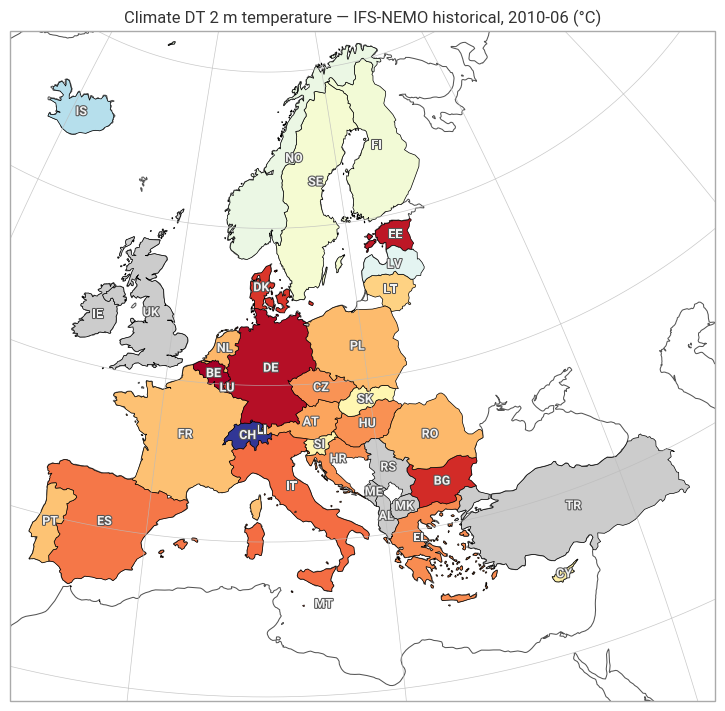

In [59]:
chart_cdt = earthkit.plots.Map(domain="Europe")

chart_cdt.coastlines()
chart_cdt.shapes(
    shapefile_path,
    labels="NUTS_ID",
    facecolor=gdf_cdt["facecolor"],
    cmap="RdYlBu_r",
    edgecolor="black",
    linewidth=0.5,
)
chart_cdt.gridlines(draw_labels=False)
chart_cdt.title(f"Climate DT 2 m temperature — {CDT_MODEL.upper()} historical, {CDT_YEAR}-{CDT_MONTH.zfill(2)} (°C)")
chart_cdt.show()

---
## Part 3 — Climate Health Hazard Index

We combine two independently normalised pillars into a composite **Climate Health Hazard Score** for each country:

```
HazardScore = w_climate × ClimateScore + w_vuln × VulnerabilityScore
```

| Pillar | Source | Variable | Rationale |
|--------|--------|----------|-----------|
| **Climate** | Climate DT (`clmn`, `avg_2t`) | Mean summer (JJA) temperature | Direct heat exposure; computed for a **present** baseline (hist 2005–2014) and a **future** scenario (SSP3-7.0 2040–2049) |
| **Vulnerability** | Eurostat `tps00010` | Share of population aged 65+ | Older people are the primary mortality group in heat waves; higher share = more vulnerable |

Three maps are produced:
1. **Present hazard** — composite score using hist baseline temperatures
2. **Future hazard** — composite score using SSP3-7.0 mid-century temperatures
3. **Change** — future minus present, showing where risk increases most

> **Note:** The Climate DT requests in this section fetch multi-month data (June–August) for a 10-year period per scenario.  
> Each request may take several minutes. Set `LIVE_REQUEST = False` to use cached files after the first run.

In [60]:
# ── Fetch elderly population share (65+) from Eurostat ───────────────────────
# Dataset TPS00010: share of population aged 65 and over, most recent year
url_elderly = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/"
    "tps00010?lang=EN&time=2023"
)
resp_elderly = requests.get(url_elderly)
data_elderly = resp_elderly.json()

geo_idx = data_elderly['dimension']['geo']['category']['index']
elderly_rows = []
for code, pos in geo_idx.items():
    if str(pos) in data_elderly['value'] and code not in ('EU27_2020', 'EA20', 'EA19'):
        elderly_rows.append((code, data_elderly['value'][str(pos)]))

df_elderly = pd.DataFrame(elderly_rows, columns=['geo', 'elderly_pct'])
print(f"Elderly share data for {len(df_elderly)} countries")
df_elderly

Elderly share data for 39 countries


,geo,elderly_pct
0,BE,16.5
1,BG,14.2
2,CZ,16.2
3,DK,16.0
4,DE,14.0
5,EE,16.4
6,IE,19.3
7,EL,13.3
8,ES,13.6
9,FR,17.2


In [ ]:
# ── Configuration for hazard Climate DT requests ─────────────────────────────
HAZARD_MODEL   = "ifs-nemo"
HAZARD_PARAM   = "avg_2t"      # Time-mean 2 m temperature [K]
HAZARD_ADDRESS = "polytope.mn5.apps.dte.destination-earth.eu"

# Summer months (JJA) — we request each month separately and average
JJA_MONTHS = ["06", "07", "08"]

# Present baseline: historical run, 2005–2014
HIST_YEARS  = range(2005, 2015)
# Future scenario: SSP3-7.0, 2040–2049
FUTURE_YEARS = range(2040, 2050)

country_codes   = list(COUNTRY_CENTROIDS.keys())
centroid_points = [[v[1], v[2]] for v in COUNTRY_CENTROIDS.values()]

def make_hazard_request(experiment, years, month):
    """Build a Polytope timeseries request for all country centroids."""
    activity = "baseline" if experiment == "hist" else "projections"
    return {
        "activity":    activity,
        "class":       "d1",
        "dataset":     "climate-dt",
        "experiment":  experiment,
        "generation":  "2",
        "levtype":     "sfc",
        "year":        "/".join(str(y) for y in years),
        "month":       str(int(month)),  # strip leading zero
        "model":       HAZARD_MODEL,
        "expver":      "0001",
        "param":       HAZARD_PARAM,
        "realization": "1",
        "resolution":  "standard",
        "stream":      "clmn",
        "type":        "fc",
        "feature": {
            "type":      "timeseries",
            "points":    centroid_points,
            "time_axis": "month",
        },
    }

print("Request builder ready")

Request builder ready


In [62]:
# ── Fetch present baseline (hist JJA 2005–2014) ──────────────────────────────
# One request per summer month; results are averaged across months and years.
import os

hist_arrays = []
for month in JJA_MONTHS:
    cache = f"data/hazard_hist_{month}.covjson"
    req   = make_hazard_request("hist", HIST_YEARS, month)
    if LIVE_REQUEST:
        raw = earthkit.data.from_source(
            "polytope", "destination-earth", req,
            address=HAZARD_ADDRESS, stream=False
        )
        raw.to_target("file", cache)
    else:
        raw = earthkit.data.from_source("file", cache)
    ds = raw.to_xarray()
    # to_xarray() returns a list of Datasets (one per point) for multi-point requests.
    # Extract the scalar from each and stack into a (n_countries,) array.
    vals = np.array([float(d[HAZARD_PARAM].values.flat[0]) for d in ds])  # K
    hist_arrays.append(vals)
    print(f"  hist month {month}: {len(vals)} country values")

# Mean over all JJA months and all years → one value per country
import numpy as np
T_hist_K = np.nanmean(np.concatenate(hist_arrays, axis=0), axis=0)  # (n_countries,)
T_hist_C = T_hist_K - 273.15
print(f"\nHistorical JJA mean 2 m temperature (°C): min={T_hist_C.min():.1f}, max={T_hist_C.max():.1f}")

2026-05-22 11:36:50 - INFO - Key read from /Users/maaw/.polytopeapirc
2026-05-22 11:36:50 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 50.85\n'
            '    - 4.35\n'
            '  - - 42.73\n'
            '    - 25.48\n'
            '  - - 49.82\n'
            '    - 15.47\n'
            '  - - 56.26\n'
            '    - 9.5\n'
            '  - - 51.17\n'
            '    - 10.45\n'
            '  - - 58.6\n'
            '    - 25.01\n'
            '  - - 39.07\n'
            '    - 21.82\n'
            '  - - 40.42\n'
            '    - -3.7\n'
            '  - - 46.23\n'
            '    - 2.21\n'
            '  - - 45.1\n'
            '    - 15.2\n'
            '  - - 41.87\n'
            '    - 12.57\n'
            '  - - 35.13\n'
            '    - 33.43\n'
      

HTTPResponseError: Polytope error
Situation: trying to download data
Description: HTTP CLIENT ERROR (400)
URL: https://polytope.lumi.apps.dte.destination-earth.eu:443/api/v1/requests/b95eb5c8-1be8-44ee-93c9-c6a7f2f2cbed
HTTP method: GET
Request header/body contents:
{'headers': {'Authorization': 'EmailKey **********71c9'}, 'json': None}
Expected responses: 200, 202
Received response: CLIENT ERROR (400)
Details:
Request failed with error:
Matched datasource polytope-climate

Polytope Feature Extraction Error: No data for {'activity': 'baseline', 'class': 'd1', 'dataset': 'climate-dt', 'experiment': 'hist', 'expver': '0001', 'generation': '2', 'levtype': 'sfc', 'model': 'ifs-nemo', 'month': '06', 'param': '228004', 'realization': '1', 'resolution': 'standard', 'stream': 'clmn', 'type': 'fc'} is available on the FDB.

In [ ]:
# ── Fetch future scenario (SSP3-7.0 JJA 2040–2049) ───────────────────────────
future_arrays = []
for month in JJA_MONTHS:
    cache = f"data/hazard_ssp370_{month}.covjson"
    req   = make_hazard_request("SSP3-7.0", FUTURE_YEARS, month)
    if LIVE_REQUEST:
        raw = earthkit.data.from_source(
            "polytope", "destination-earth", req,
            address=HAZARD_ADDRESS, stream=False
        )
        raw.to_target("file", cache)
    else:
        raw = earthkit.data.from_source("file", cache)
    ds = raw.to_xarray()
    vals = np.array([float(d[HAZARD_PARAM].values.flat[0]) for d in ds])  # K
    future_arrays.append(vals)
    print(f"  SSP3-7.0 month {month}: {len(vals)} country values")

T_future_K = np.nanmean(np.concatenate(future_arrays, axis=0), axis=0)
T_future_C = T_future_K - 273.15
print(f"\nFuture JJA mean 2 m temperature (°C): min={T_future_C.min():.1f}, max={T_future_C.max():.1f}")

In [ ]:
# ── Build the hazard index ────────────────────────────────────────────────────
# Weights: 60% climate exposure, 40% demographic vulnerability
W_CLIMATE = 0.6
W_VULN    = 0.4

def minmax(arr):
    """Min-max normalise a numpy array to [0, 1]."""
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    return (arr - lo) / (hi - lo)

# Align elderly data to the country_codes order
elderly_map = df_elderly.set_index('geo')['elderly_pct'].to_dict()
elderly_arr = np.array([elderly_map.get(c, np.nan) for c in country_codes])

# Normalise each pillar
climate_score_hist   = minmax(T_hist_C)
climate_score_future = minmax(T_future_C)
vuln_score           = minmax(elderly_arr)

# Composite scores
hazard_present = W_CLIMATE * climate_score_hist   + W_VULN * vuln_score
hazard_future  = W_CLIMATE * climate_score_future + W_VULN * vuln_score
hazard_delta   = hazard_future - hazard_present

# Assemble into a single DataFrame
df_hazard = pd.DataFrame({
    'geo':            country_codes,
    'T_hist_C':       T_hist_C,
    'T_future_C':     T_future_C,
    'delta_T':        T_future_C - T_hist_C,
    'elderly_pct':    elderly_arr,
    'vuln_score':     vuln_score,
    'hazard_present': hazard_present,
    'hazard_future':  hazard_future,
    'hazard_delta':   hazard_delta,
})

print(df_hazard[['geo', 'T_hist_C', 'T_future_C', 'delta_T', 'elderly_pct',
                 'hazard_present', 'hazard_future', 'hazard_delta']].to_string(index=False))

In [ ]:
# ── Helper: merge hazard scores onto NUTS shapefile and plot ──────────────────
def plot_hazard_map(gdf_nuts, df_scores, score_col, title, cmap_name="YlOrRd",
                   diverging=False):
    """Merge `score_col` from df_scores onto gdf_nuts and render a choropleth."""
    cmap_obj = plt.get_cmap(cmap_name)
    vals = df_scores[score_col].values
    if diverging:
        # Centre the colormap at zero for delta maps
        abs_max = np.nanmax(np.abs(vals))
        norm_obj = plt.Normalize(vmin=-abs_max, vmax=abs_max)
    else:
        norm_obj = plt.Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))

    df_plot = df_scores[['geo', score_col]].copy()
    df_plot['facecolor'] = df_plot[score_col].apply(
        lambda x: plt.cm.colors.to_hex(cmap_obj(norm_obj(x)))
        if not np.isnan(x) else '#cccccc'
    )

    gdf_merged = gdf_nuts.merge(df_plot, left_on='NUTS_ID', right_on='geo', how='left')
    if not isinstance(gdf_merged, gpd.GeoDataFrame):
        gdf_merged = gpd.GeoDataFrame(gdf_merged, geometry=gdf_nuts.geometry,
                                      crs=gdf_nuts.crs)
    gdf_merged['facecolor'] = gdf_merged['facecolor'].fillna('#cccccc')

    chart = earthkit.plots.Map(domain='Europe')
    chart.coastlines()
    chart.shapes(
        shapefile_path,
        labels='NUTS_ID',
        facecolor=gdf_merged['facecolor'],
        cmap=cmap_name,
        edgecolor='black',
        linewidth=0.5,
    )
    chart.gridlines(draw_labels=False)
    chart.title(title)
    chart.show()

print("plot_hazard_map() defined")

In [ ]:
# ── Map 1: Present hazard (hist 2005–2014 + elderly share 2023) ───────────────
plot_hazard_map(
    gdf,
    df_hazard,
    score_col='hazard_present',
    title=(
        f"Climate Health Hazard — Present\n"
        f"({W_CLIMATE:.0%} summer heat, {W_VULN:.0%} elderly share | "
        f"Climate DT hist 2005–2014, Eurostat 2023)"
    ),
    cmap_name='YlOrRd',
)

In [ ]:
# ── Map 2: Future hazard (SSP3-7.0 2040–2049 + same elderly share) ────────────
plot_hazard_map(
    gdf,
    df_hazard,
    score_col='hazard_future',
    title=(
        f"Climate Health Hazard — Future (SSP3-7.0)\n"
        f"({W_CLIMATE:.0%} summer heat, {W_VULN:.0%} elderly share | "
        f"Climate DT SSP3-7.0 2040–2049, Eurostat 2023)"
    ),
    cmap_name='YlOrRd',
)

In [ ]:
# ── Map 3: Change in hazard (future − present) ────────────────────────────────
# Diverging colormap centred at zero: blue = decreasing risk, red = increasing risk
plot_hazard_map(
    gdf,
    df_hazard,
    score_col='hazard_delta',
    title=(
        "Change in Climate Health Hazard\n"
        "(Future SSP3-7.0 2040–2049 minus Present hist 2005–2014)"
    ),
    cmap_name='RdBu_r',
    diverging=True,
)

In [ ]:
# ── Summary table: top 10 countries by future hazard score ───────────────────
top10 = (
    df_hazard[['geo', 'T_hist_C', 'T_future_C', 'delta_T',
               'elderly_pct', 'hazard_present', 'hazard_future', 'hazard_delta']]
    .sort_values('hazard_future', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.columns = [
    'Country', 'T hist (°C)', 'T future (°C)', 'ΔT (°C)',
    'Elderly (%)', 'Hazard present', 'Hazard future', 'Δ Hazard'
]
top10.style.background_gradient(subset=['Hazard future'], cmap='YlOrRd')